# PRM Rollouts Evaluation Analysis

This notebook analyzes the evaluated rollouts from our Process Reward Model experiments.


In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from IPython.display import display

# Create charts directory
os.makedirs('charts', exist_ok=True)

# Set up scientific plotting theme
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'font.family': 'serif',
    'axes.grid': True,
    'grid.alpha': 0.5,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False
})

sns.set_theme(style="whitegrid", palette="colorblind")


## Data Loading
Loading the evaluated rollouts and joining with metadata.


In [2]:
# Load metadata
with open('../data/CharXiv/data/image_metadata_val.json', 'r') as f:
    meta = json.load(f)

with open('../data/CharXiv/data/chart_types_val.json', 'r') as f:
    chart_types = json.load(f)

# Load the dataset
data_path = Path('../experiments/001_500_reasoning/data/evaluated_rollouts.jsonl')
data = []
with open(data_path, 'r') as f:
    for line in f:
        data.append(json.loads(line))

# Flatten into step-level dataframe
rows = []
for item in data:
    q_id = str(item['question_id'])
    r_idx = item['rollout_index']
    cat = meta.get(q_id, {}).get('category', 'unknown')
    
    ctype_list = chart_types.get(q_id, {}).get('chart_types', ['unknown'])
    ctype = ctype_list[0] if len(ctype_list) > 0 else 'unknown'
    
    evals = item.get('evaluations') or []
    for i, step in enumerate(evals):
        rows.append({
            'question_id': q_id,
            'rollout_index': r_idx,
            'category': cat,
            'chart_type': ctype,
            'step_index': step.get('step_index', i),
            'score': step.get('score'),
            'analysis_len': len(step.get('analysis', '')),
            'total_steps': len(evals)
        })

df_steps = pd.DataFrame(rows)
display(df_steps.head())


,question_id,rollout_index,category,chart_type,step_index,score,analysis_len,total_steps
0,20,2,cs,Histogram,0,1,191,3
1,20,2,cs,Histogram,1,0,233,3
2,20,2,cs,Histogram,2,0,219,3
3,14,1,cs,Bubble Chart,0,1,129,4
4,14,1,cs,Bubble Chart,1,0,183,4


## 1. Overall Step-Level Accuracy Distribution
This plot shows the overall distribution of scores (0 and 1) across all individual reasoning steps.


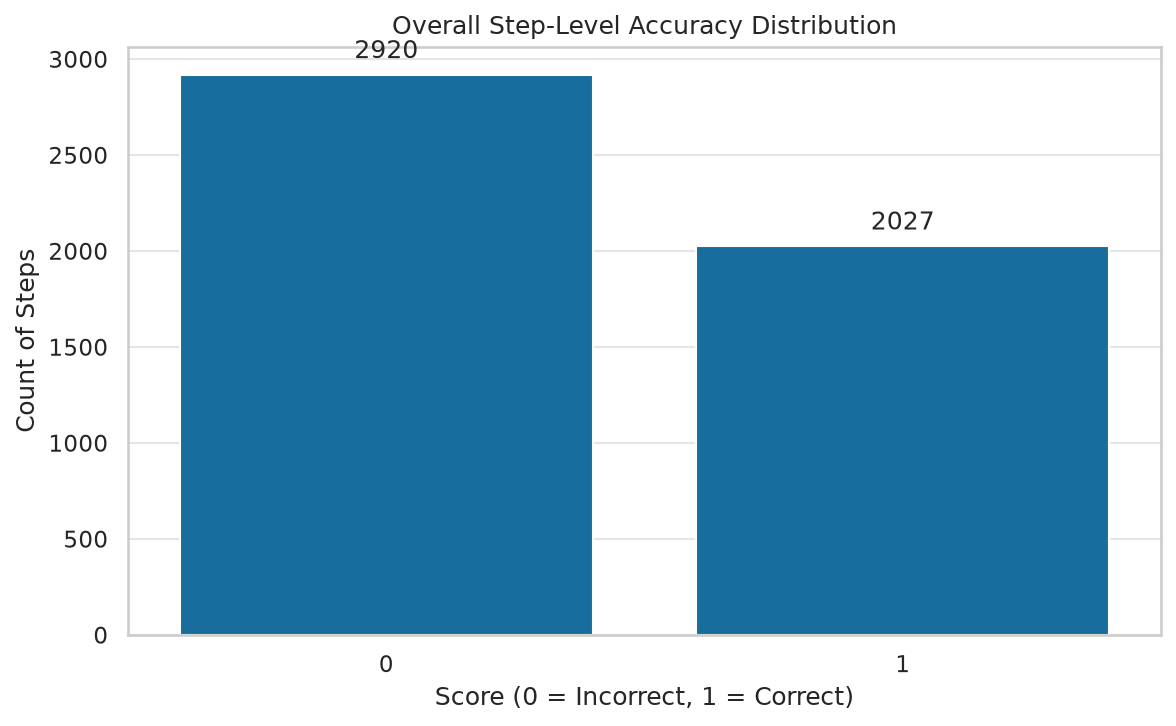

In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_steps, x='score')
plt.title('Overall Step-Level Accuracy Distribution')
plt.xlabel('Score (0 = Incorrect, 1 = Correct)')
plt.ylabel('Count of Steps')

# Annotate counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('charts/01_overall_accuracy.png')
plt.show()


## 2. Score Progression by Step Index
How does the average score change as we progress deeper into a rollout? Are later steps more likely to be wrong?


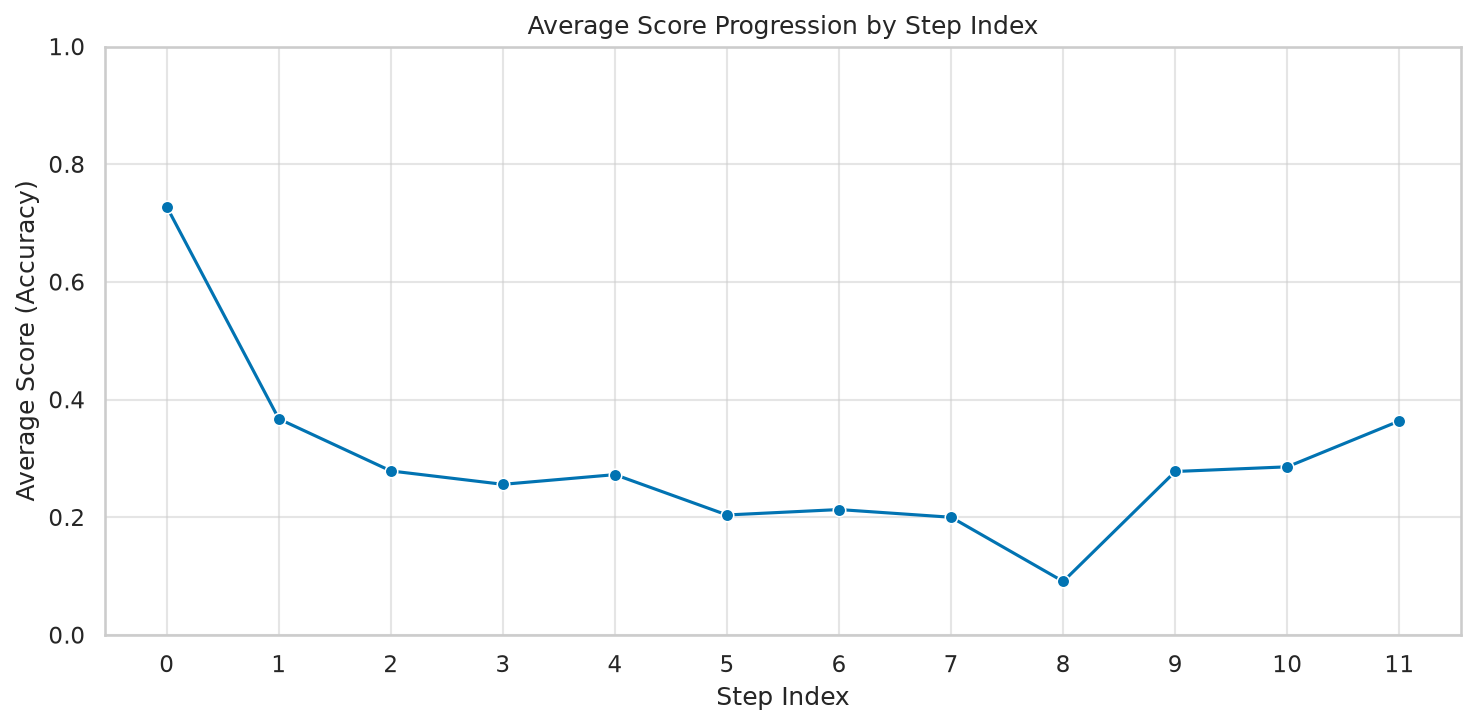

In [4]:
plt.figure(figsize=(10, 5))
step_acc = df_steps.groupby('step_index')['score'].mean().reset_index()
# Filter out very long steps with too few samples to reduce noise
step_counts = df_steps['step_index'].value_counts()
valid_steps = step_counts[step_counts > 10].index
step_acc = step_acc[step_acc['step_index'].isin(valid_steps)]

sns.lineplot(data=step_acc, x='step_index', y='score', marker='o')
plt.title('Average Score Progression by Step Index')
plt.xlabel('Step Index')
plt.ylabel('Average Score (Accuracy)')
plt.xticks(step_acc['step_index'])
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('charts/02_score_progression.png')
plt.show()


## 3. Rollout Success Rate
A rollout is entirely correct if all its steps have a score of 1. Here we visualize the proportion of perfect rollouts vs those with at least one error.


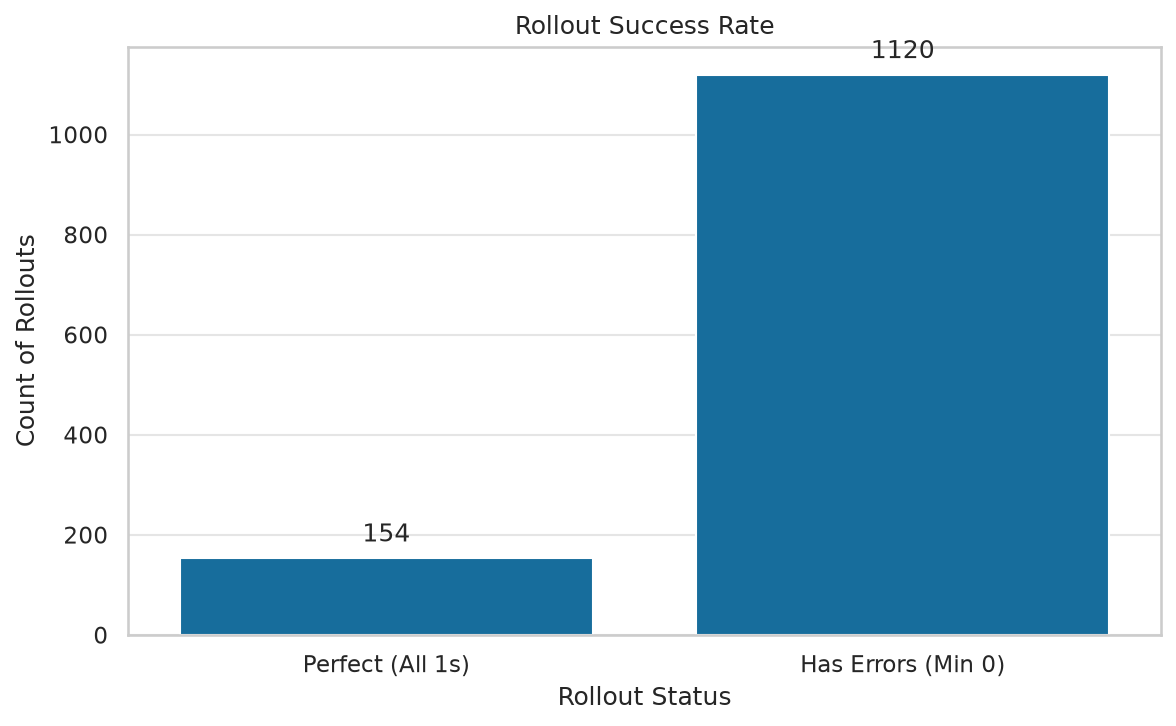

In [5]:
# Calculate rollout success
rollout_success = df_steps.groupby(['question_id', 'rollout_index'])['score'].min().reset_index()
rollout_success['status'] = rollout_success['score'].map({1: 'Perfect (All 1s)', 0: 'Has Errors (Min 0)'})

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=rollout_success, x='status', order=['Perfect (All 1s)', 'Has Errors (Min 0)'])
plt.title('Rollout Success Rate')
plt.xlabel('Rollout Status')
plt.ylabel('Count of Rollouts')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('charts/03_rollout_success.png')
plt.show()


## 4. First Error Position Analysis
For rollouts that have errors, at which step index does the model typically make its first mistake?


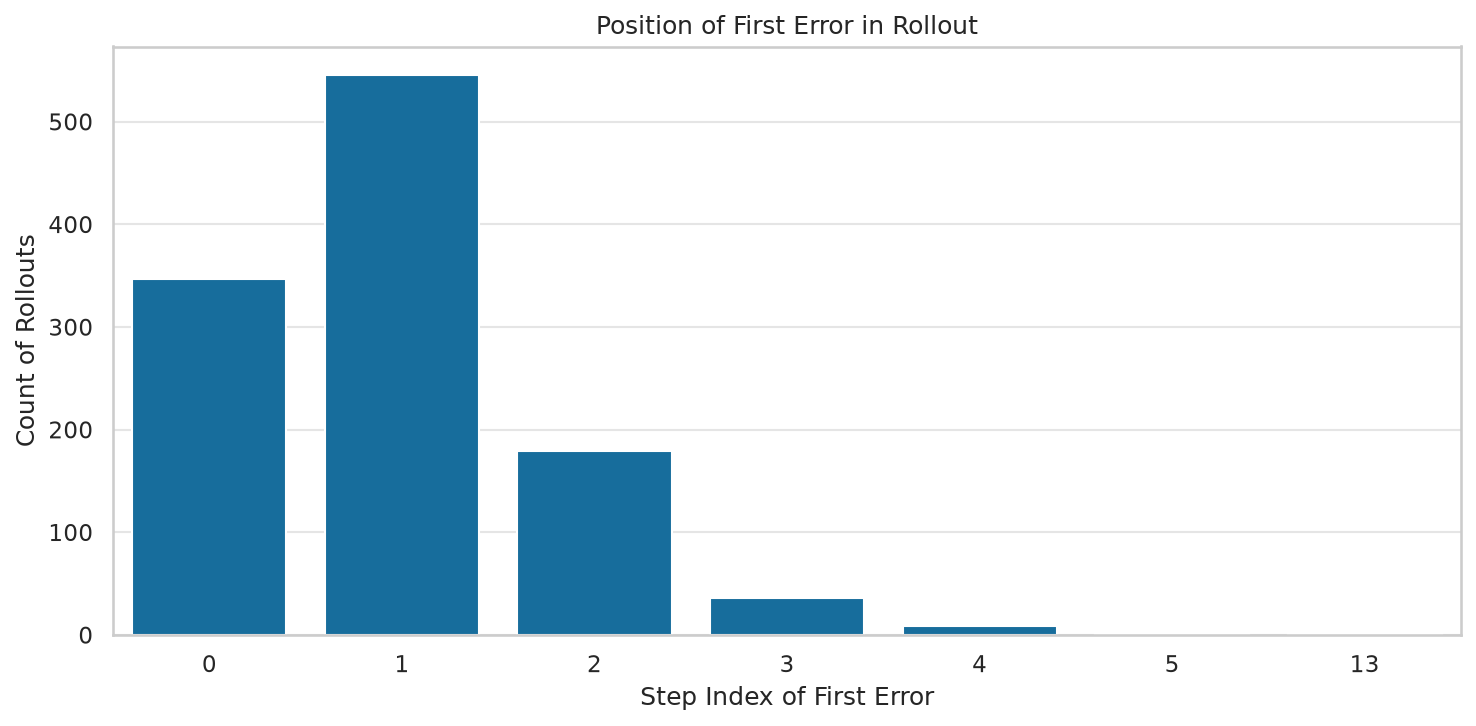

In [6]:
errors = df_steps[df_steps['score'] == 0]
first_errors = errors.groupby(['question_id', 'rollout_index'])['step_index'].min().reset_index()

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=first_errors, x='step_index')
plt.title('Position of First Error in Rollout')
plt.xlabel('Step Index of First Error')
plt.ylabel('Count of Rollouts')

plt.tight_layout()
plt.savefig('charts/04_first_error_position.png')
plt.show()


## 5. Question Difficulty Ranking
Distribution of average rollout success rate across different questions. This shows if some questions are universally hard or easy.


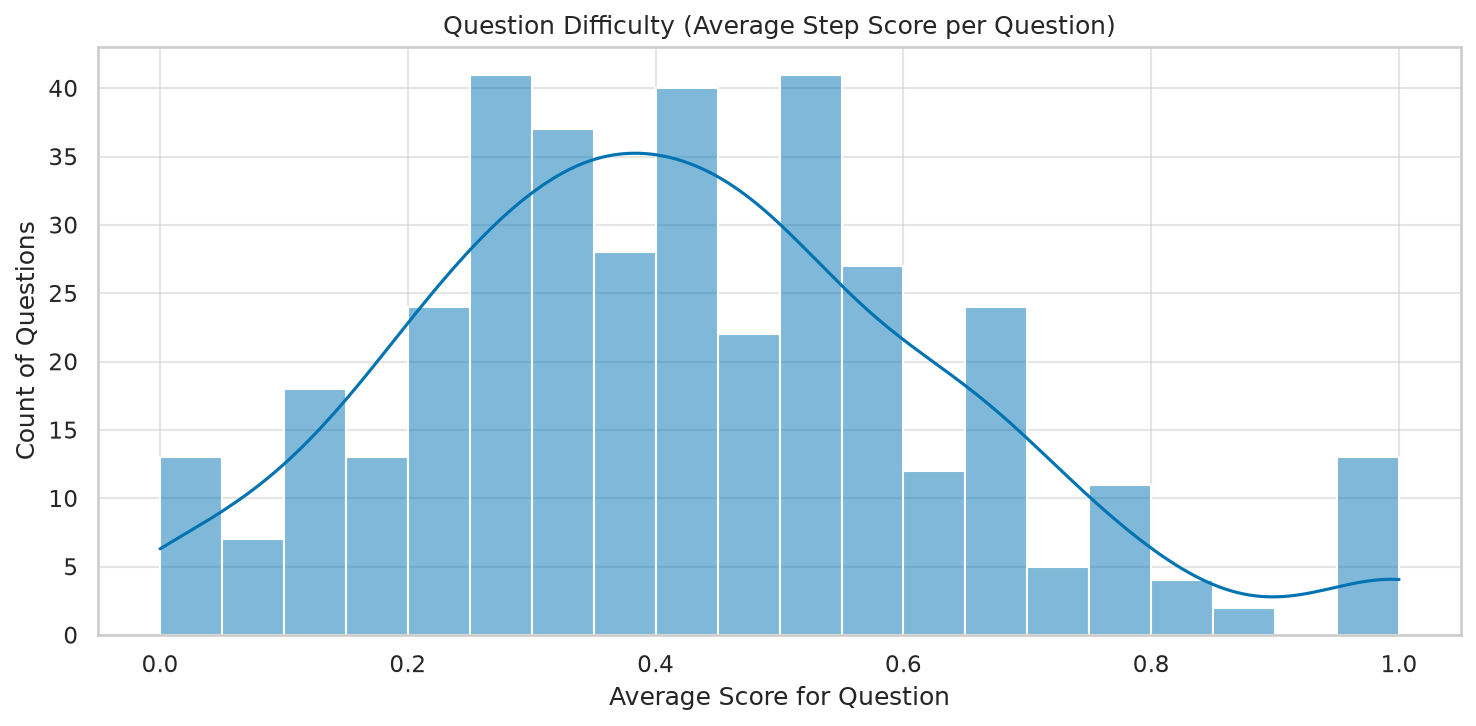

In [7]:
q_acc = df_steps.groupby('question_id')['score'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.histplot(data=q_acc, x='score', bins=20, kde=True)
plt.title('Question Difficulty (Average Step Score per Question)')
plt.xlabel('Average Score for Question')
plt.ylabel('Count of Questions')

plt.tight_layout()
plt.savefig('charts/05_question_difficulty.png')
plt.show()


## 6. Rollout Length vs. Accuracy
Does the total number of steps in a rollout correlate with the average accuracy of its steps?


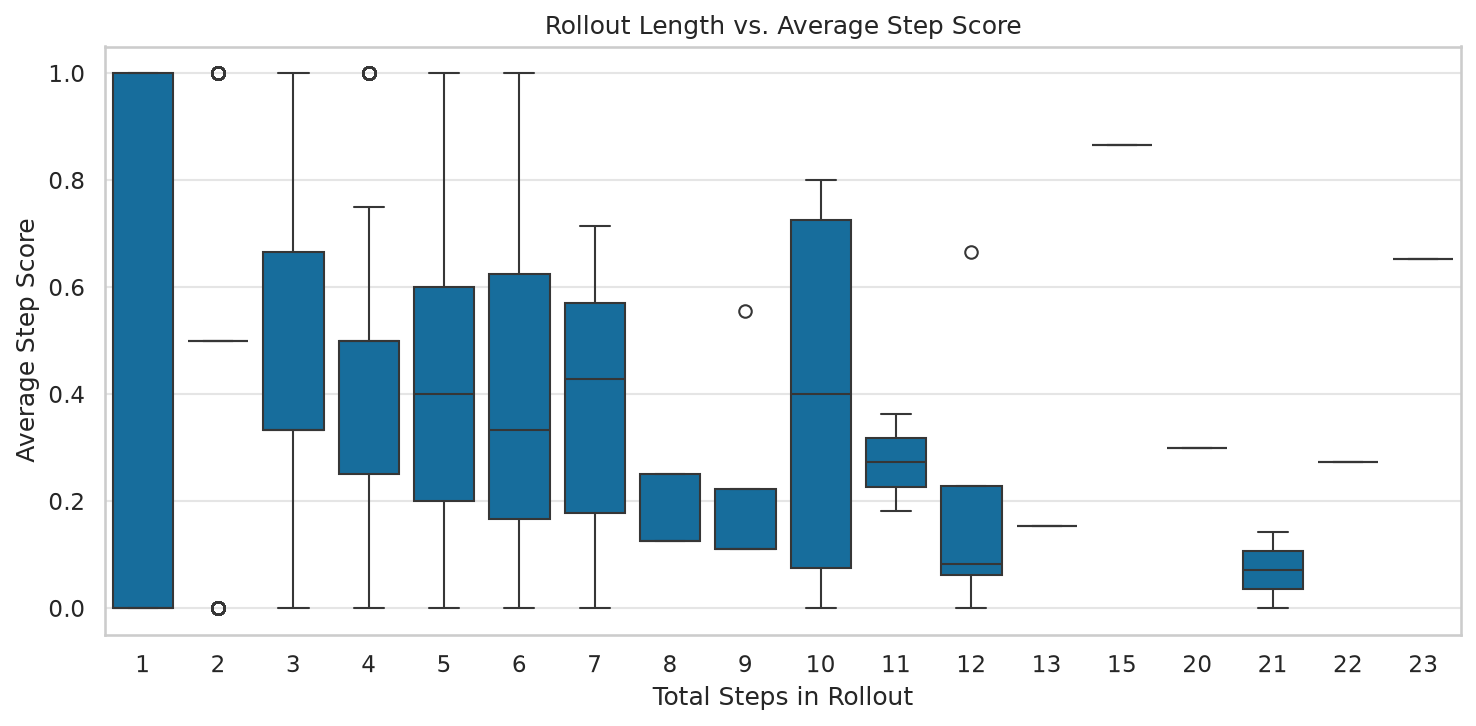

In [8]:
rollout_stats = df_steps.groupby(['question_id', 'rollout_index']).agg({
    'score': 'mean',
    'total_steps': 'first'
}).reset_index()

plt.figure(figsize=(10, 5))
sns.boxplot(data=rollout_stats, x='total_steps', y='score')
plt.title('Rollout Length vs. Average Step Score')
plt.xlabel('Total Steps in Rollout')
plt.ylabel('Average Step Score')

plt.tight_layout()
plt.savefig('charts/06_length_vs_accuracy.png')
plt.show()


## 7. Score Variance per Question
How much variance is there in step scores for a given question? A high variance implies the model is inconsistent on that question.


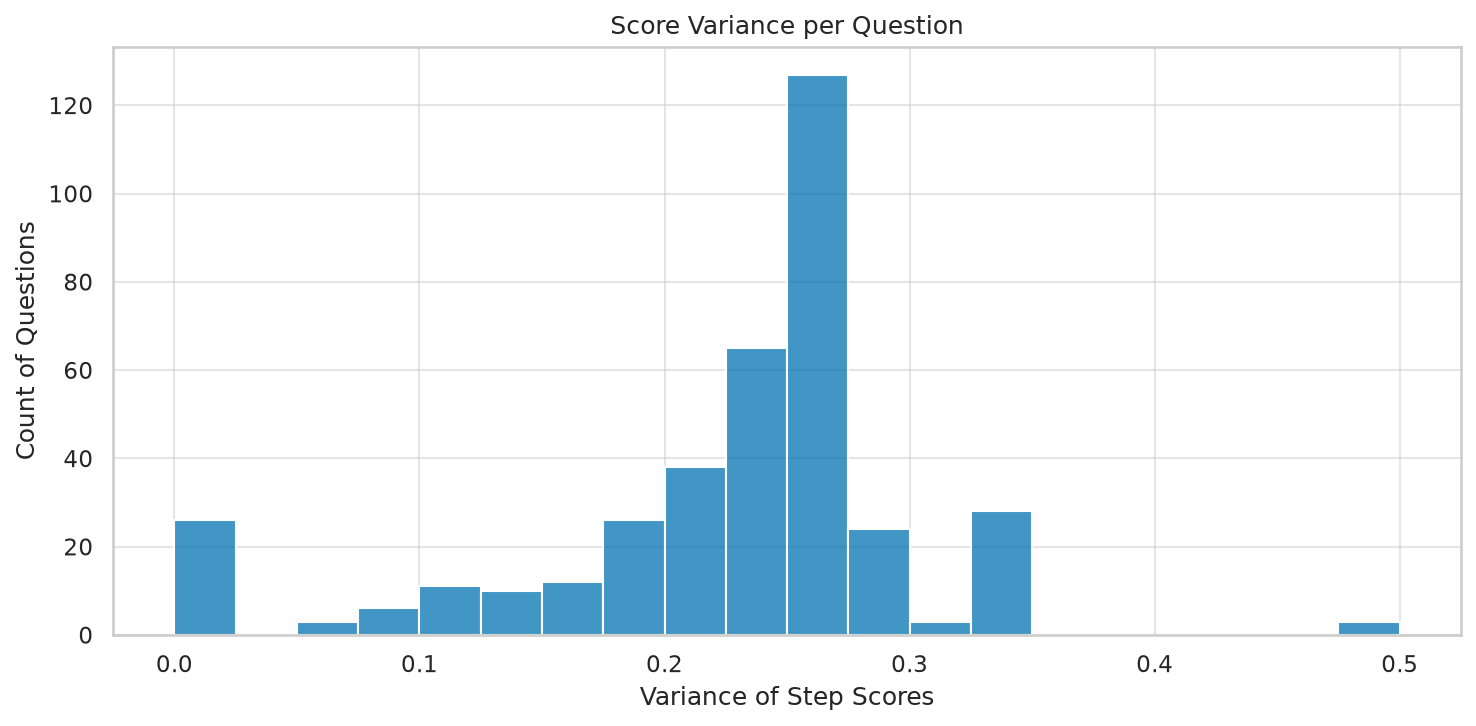

In [9]:
q_var = df_steps.groupby('question_id')['score'].var().fillna(0).reset_index()

plt.figure(figsize=(10, 5))
sns.histplot(data=q_var, x='score', bins=20)
plt.title('Score Variance per Question')
plt.xlabel('Variance of Step Scores')
plt.ylabel('Count of Questions')

plt.tight_layout()
plt.savefig('charts/07_score_variance.png')
plt.show()


## 8. Error Cascade Analysis
If step N is incorrect, what is the score distribution for step N+1? Does an error cascade into more errors?


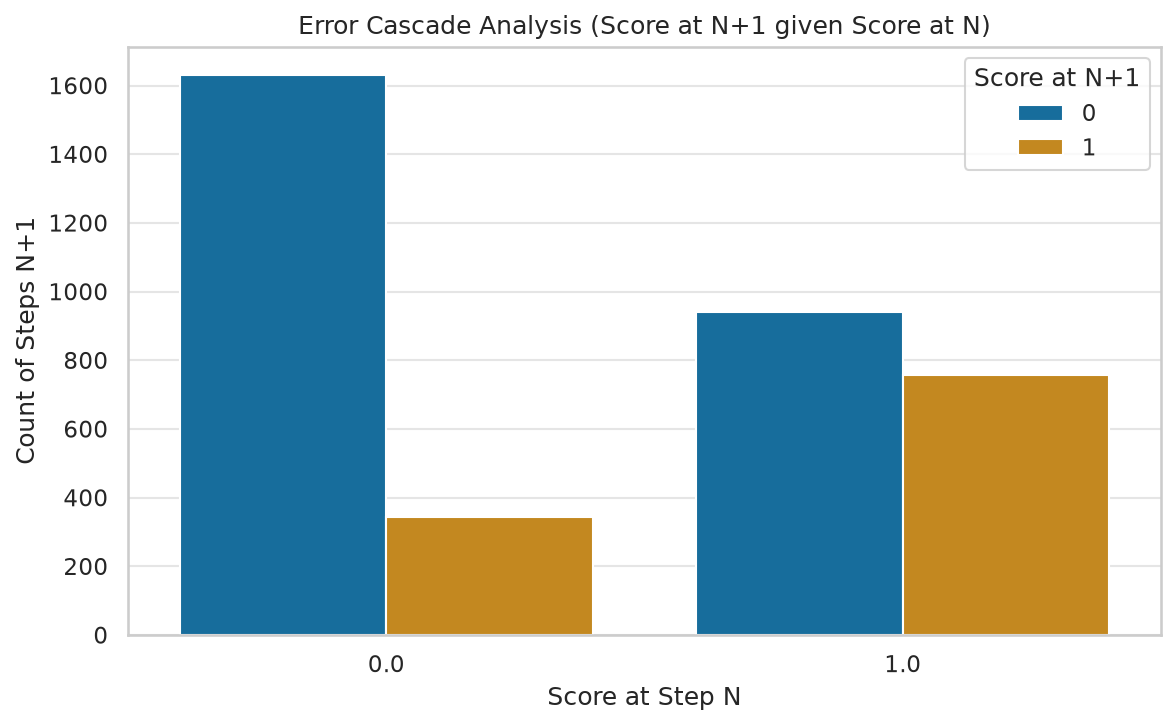

In [10]:
# Shift scores within the same rollout to get the 'previous_score'
df_steps = df_steps.sort_values(['question_id', 'rollout_index', 'step_index'])
df_steps['prev_score'] = df_steps.groupby(['question_id', 'rollout_index'])['score'].shift(1)

cascade_data = df_steps.dropna(subset=['prev_score'])

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=cascade_data, x='prev_score', hue='score')
plt.title('Error Cascade Analysis (Score at N+1 given Score at N)')
plt.xlabel('Score at Step N')
plt.ylabel('Count of Steps N+1')
plt.legend(title='Score at N+1')

plt.tight_layout()
plt.savefig('charts/08_error_cascade.png')
plt.show()


## 9. Analysis Text Length Correlation
Does the length of the PRM's textual analysis correlate with the score? Do negative scores require longer explanations?


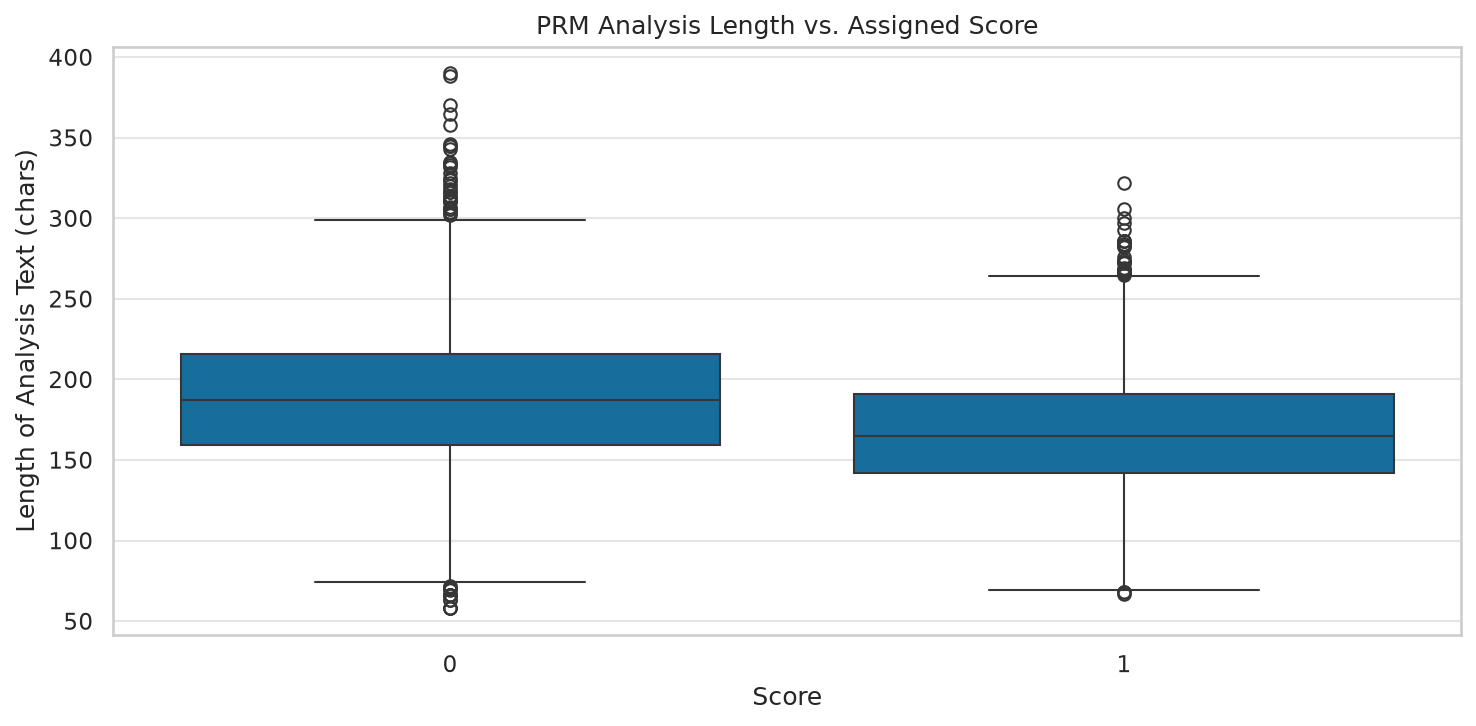

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_steps, x='score', y='analysis_len')
plt.title('PRM Analysis Length vs. Assigned Score')
plt.xlabel('Score')
plt.ylabel('Length of Analysis Text (chars)')

plt.tight_layout()
plt.savefig('charts/09_analysis_length.png')
plt.show()


## 10. Terminal State Analysis
The correctness of the final step often dictates the final answer. What is the accuracy of exclusively the final steps?


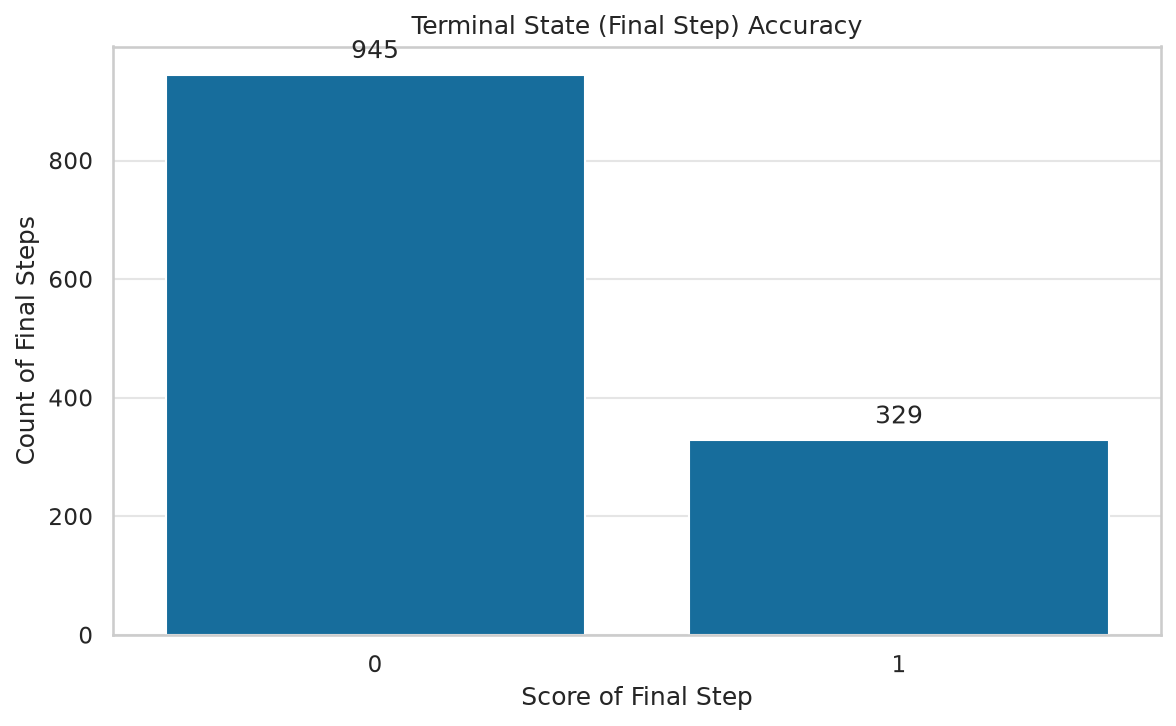

In [12]:
terminal_steps = df_steps[df_steps['step_index'] == (df_steps['total_steps'] - 1)]

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=terminal_steps, x='score')
plt.title('Terminal State (Final Step) Accuracy')
plt.xlabel('Score of Final Step')
plt.ylabel('Count of Final Steps')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('charts/10_terminal_accuracy.png')
plt.show()


## 11. Domain (Category) Analysis
Analyzing the accuracy across different academic domains or categories from CharXiv metadata.


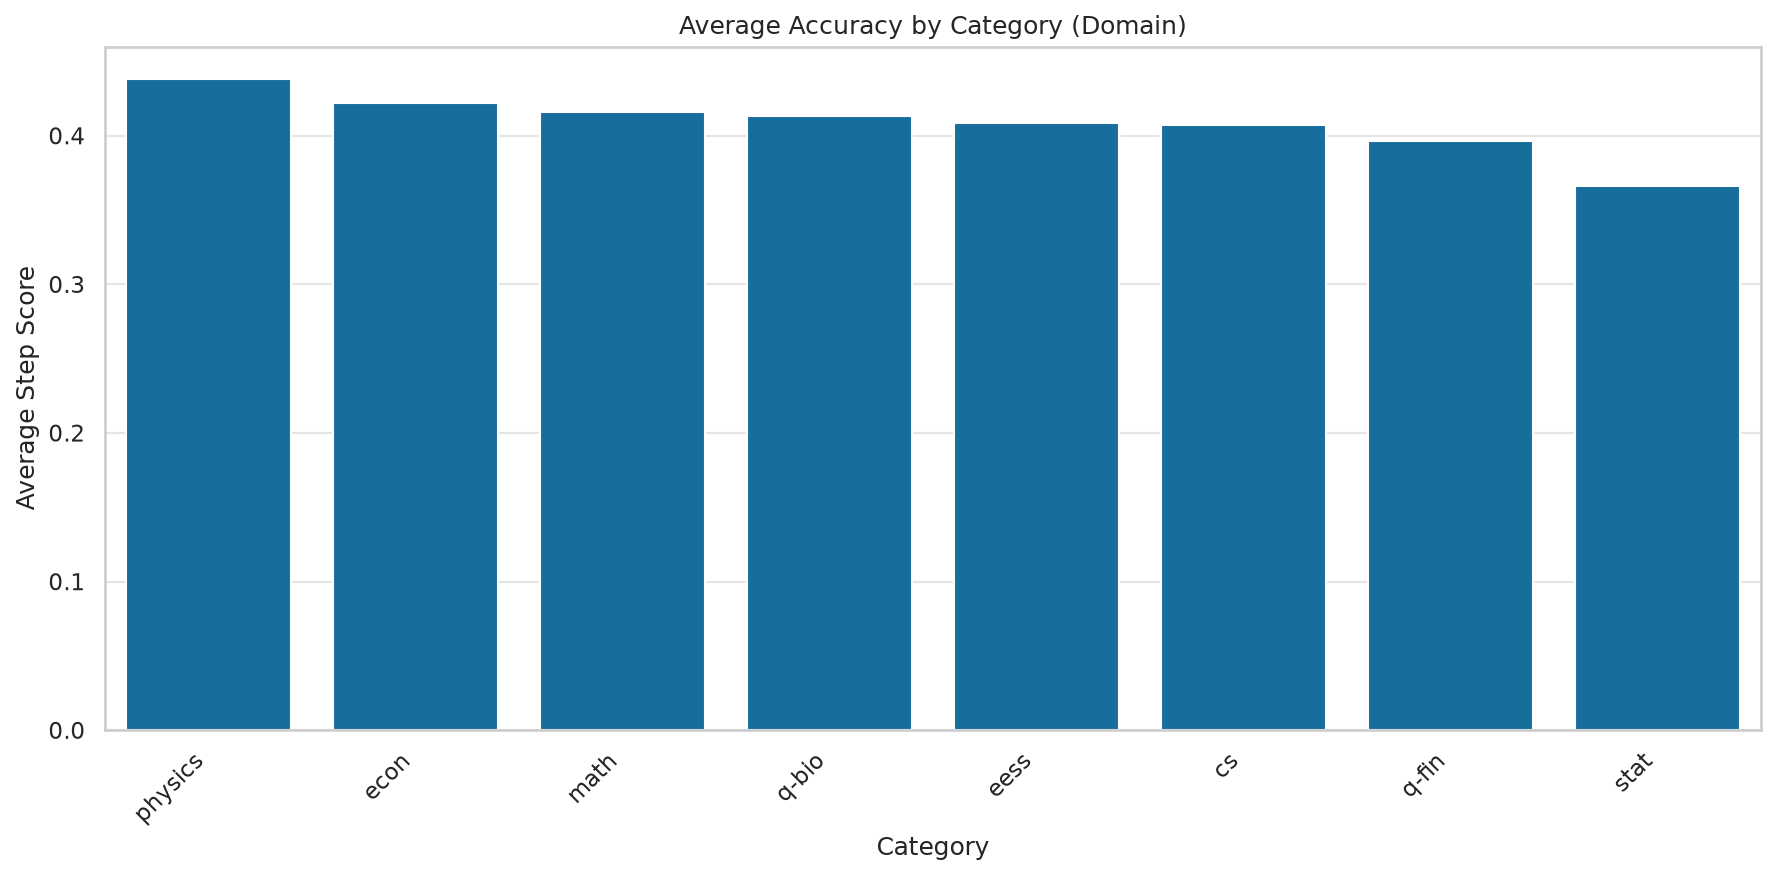

In [13]:
cat_acc = df_steps.groupby('category')['score'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=cat_acc, x='category', y='score')
plt.title('Average Accuracy by Category (Domain)')
plt.xlabel('Category')
plt.ylabel('Average Step Score')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('charts/11_domain_accuracy.png')
plt.show()


## 12. Chart Type Analysis
Analyzing the accuracy broken down by the top 15 most frequent chart types.


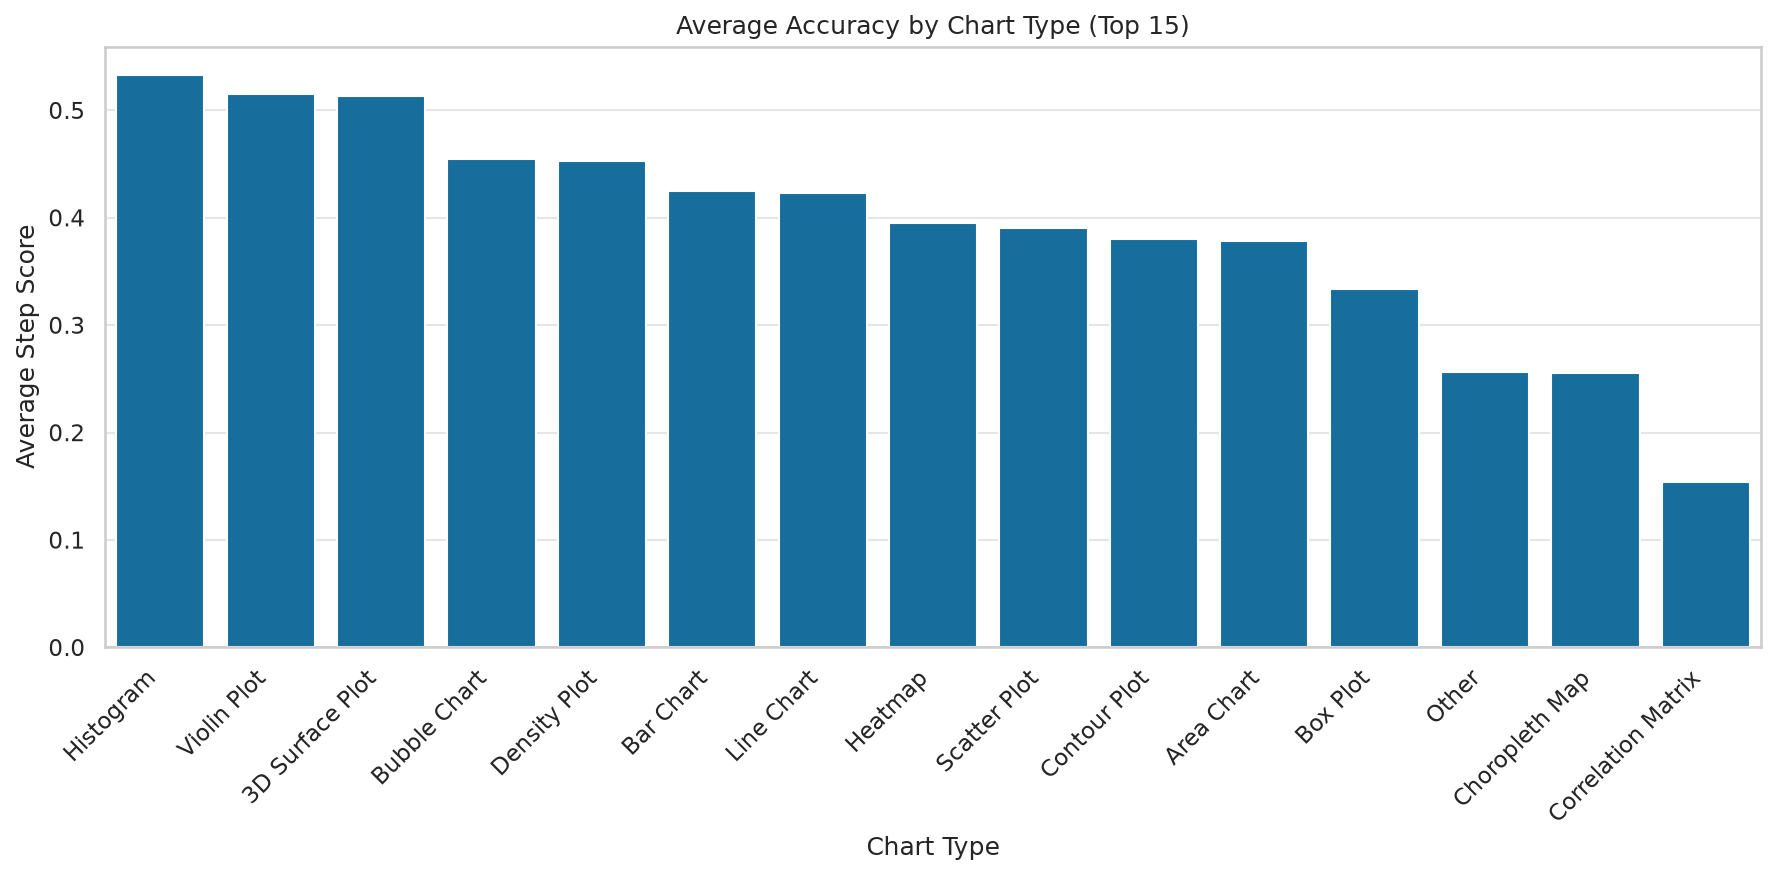

In [14]:
# Filter to top 15 chart types by step count to avoid clutter
top_chart_types = df_steps['chart_type'].value_counts().nlargest(15).index
df_top_charts = df_steps[df_steps['chart_type'].isin(top_chart_types)]

chart_acc = df_top_charts.groupby('chart_type')['score'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=chart_acc, x='chart_type', y='score')
plt.title('Average Accuracy by Chart Type (Top 15)')
plt.xlabel('Chart Type')
plt.ylabel('Average Step Score')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('charts/12_chart_type_accuracy.png')
plt.show()


## 13. Hallucinated Correctness (Recovery from Error)
Specifically investigating cases where Step N was scored 0, but Step N+1 was scored 1.


Total steps that recovered from 0 to 1: 343


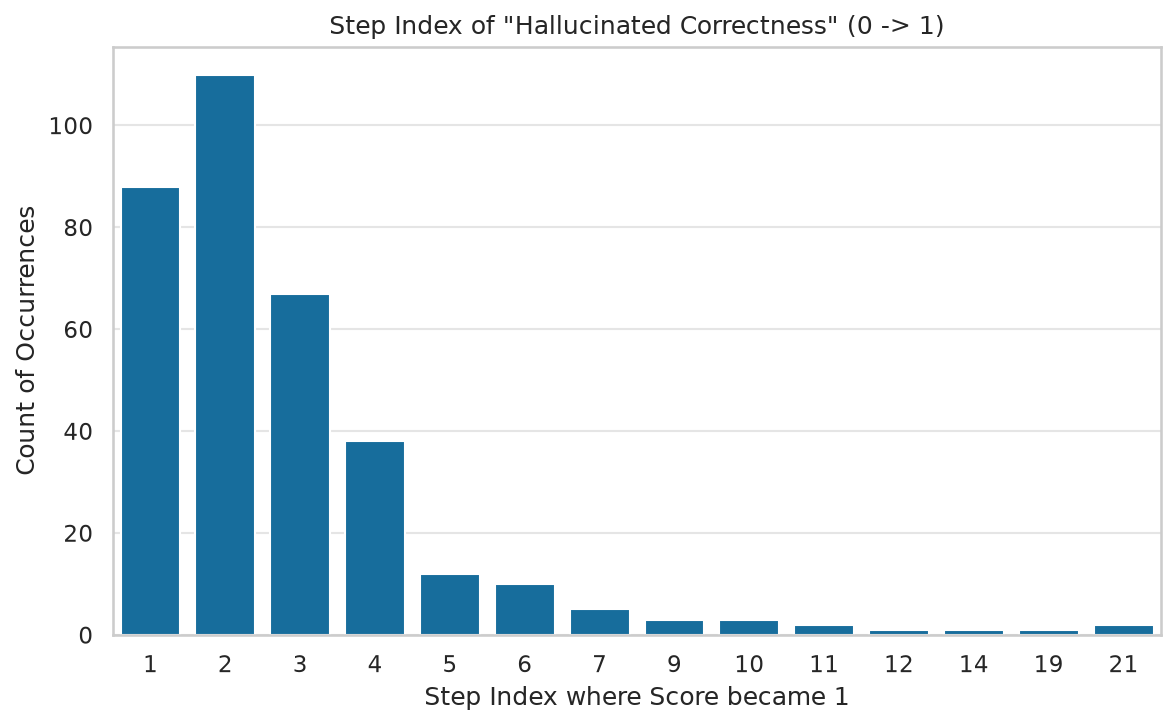


Sample of Recovery Cases:


,question_id,rollout_index,step_index,prev_score,score
2321,1009,1,2,0.0,1
2366,1011,3,3,0.0,1
2372,1011,4,2,0.0,1
2391,1028,0,1,0.0,1
2440,1044,3,4,0.0,1


In [15]:
# We already computed 'prev_score'. We want prev_score == 0 and score == 1
recovery_cases = cascade_data[(cascade_data['prev_score'] == 0) & (cascade_data['score'] == 1)]
print(f"Total steps that recovered from 0 to 1: {len(recovery_cases)}")

plt.figure(figsize=(8, 5))
# Let's see at which step indices these recoveries happen most often
if len(recovery_cases) > 0:
    ax = sns.countplot(data=recovery_cases, x='step_index')
    plt.title('Step Index of "Hallucinated Correctness" (0 -> 1)')
    plt.xlabel('Step Index where Score became 1')
    plt.ylabel('Count of Occurrences')
    plt.tight_layout()
    plt.savefig('charts/13_hallucinated_correctness.png')
    plt.show()
else:
    print("No hallucinated correctness cases found.")

# Display a few examples to understand context
if len(recovery_cases) > 0:
    display_cols = ['question_id', 'rollout_index', 'step_index', 'prev_score', 'score']
    print("\nSample of Recovery Cases:")
    display(recovery_cases[display_cols].head())
